<a href="https://colab.research.google.com/github/azrapatvi/image-classifier/blob/main/classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

folders=[
    "cat",
    "dog",
    "person",
    "table",
    "birds"
]


print(folders)

['cat', 'dog', 'person', 'table', 'birds']


In [ ]:
for folder in folders:
  path=os.path.join('current_batch/',folder)
  os.makedirs(path,exist_ok=True)
  print(f"created:{folder}")

created:cat
created:dog
created:person
created:table
created:birds


In [ ]:
for folder in folders:
  print(folder)

cat
dog
person
table
birds


In [ ]:
import os
import requests
import time

access_key = "KZ1n3mKxq8dINf6_LTwYCN4EPU0pvfigIOD8b7Dr_pM"

headers = {
    "Authorization": f"Client-ID {access_key}"
}

url = "https://api.unsplash.com/search/photos"

def download_image(url, file_path):
    response = requests.get(url).content
    with open(file_path, "wb") as handler:
        handler.write(response)

base_dir = "current_batch"

for folder in folders:
    print(f"collecting images for {folder}")

    folder_path = os.path.join(base_dir, folder)
    os.makedirs(folder_path, exist_ok=True)

    image_count = 0
    page = 1

    while image_count < 300:
        params = {
            "query": folder,
            "per_page": 30,
            "page": page
        }

        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        results = data.get("results", [])

        if not results:
            print("No more results found!")
            break

        for img in results:
            if image_count >= 300:
                break

            img_url = img["urls"]["small"]

            file_path = os.path.join(folder_path, f"{folder}_{image_count}.jpg")  # ✅ fixed

            download_image(img_url, file_path)
            image_count += 1

        print(f"{folder}: downloaded {image_count} images")

        page += 1
        time.sleep(5)

print("✅ Download completed!")

collecting images for cat
cat: downloaded 30 images
cat: downloaded 60 images
cat: downloaded 90 images
cat: downloaded 120 images
cat: downloaded 150 images
cat: downloaded 180 images
cat: downloaded 210 images
cat: downloaded 240 images
cat: downloaded 270 images
cat: downloaded 300 images
collecting images for dog
dog: downloaded 30 images
dog: downloaded 60 images
dog: downloaded 90 images
dog: downloaded 120 images
dog: downloaded 150 images
dog: downloaded 180 images
dog: downloaded 210 images
dog: downloaded 240 images
dog: downloaded 270 images
dog: downloaded 300 images
collecting images for person
person: downloaded 30 images
person: downloaded 60 images
person: downloaded 90 images
person: downloaded 120 images
person: downloaded 150 images
person: downloaded 180 images
person: downloaded 210 images
person: downloaded 240 images
person: downloaded 270 images
person: downloaded 300 images
collecting images for table
table: downloaded 30 images
table: downloaded 60 images
tabl

In [ ]:
folders


['cat', 'dog', 'person', 'table', 'birds']

In [ ]:
import os
import cv2

base_dir = "current_batch"
clean_dir = "cleaned_batch"

os.makedirs(clean_dir, exist_ok=True)

batch_size = 100


folders = os.listdir(base_dir)  # ['cat', 'dog', ...]

for folder in folders:
    counter = 1
    folder_path = os.path.join(base_dir, folder)

    if not os.path.isdir(folder_path):
        continue

    print(f"\nProcessing folder: {folder}")

    all_images = os.listdir(folder_path)

    for i in range(0, len(all_images), batch_size):

        batch = all_images[i:i+batch_size]

        print(f"\nBatch {i//batch_size + 1}")

        for img_name in batch:

            img_path = os.path.join(folder_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                print("Failed:", img_name)
                continue

            # preprocessing
            img = cv2.resize(img, (224, 224))
            img = cv2.GaussianBlur(img, (3,3), 0)

            class_dir = os.path.join(clean_dir, folder)
            os.makedirs(class_dir, exist_ok=True)

            # name image properly
            new_name = f"{folder}_{counter}.jpg"

            # final path
            save_path = os.path.join(class_dir, new_name)

            cv2.imwrite(save_path, img)

            counter += 1

print("\n✅ All images processed!")


Processing folder: table

Batch 1

Batch 2

Batch 3

Processing folder: birds

Batch 1

Batch 2

Batch 3

Processing folder: dog

Batch 1

Batch 2

Batch 3

Processing folder: person

Batch 1

Batch 2

Batch 3

Processing folder: cat

Batch 1

Batch 2

Batch 3

✅ All images processed!


In [ ]:
import numpy as np
import os

cleaned_batch=os.listdir('cleaned_batch/')
print(cleaned_batch) # list the number of foldes present

['table', 'birds', 'dog', 'person', 'cat']


In [ ]:
for folder in cleaned_batch:
  print(folder)
  print(len(os.listdir(os.path.join('cleaned_batch/',folder))))
  print()

table
300

birds
300

dog
300

person
300

cat
300



In [ ]:
for item in cleaned_batch:
  print(os.listdir('cleaned_batch/'+item))

['table_135.jpg', 'table_94.jpg', 'table_48.jpg', 'table_107.jpg', 'table_66.jpg', 'table_267.jpg', 'table_197.jpg', 'table_235.jpg', 'table_150.jpg', 'table_11.jpg', 'table_285.jpg', 'table_116.jpg', 'table_114.jpg', 'table_208.jpg', 'table_96.jpg', 'table_160.jpg', 'table_266.jpg', 'table_284.jpg', 'table_125.jpg', 'table_131.jpg', 'table_122.jpg', 'table_44.jpg', 'table_3.jpg', 'table_151.jpg', 'table_163.jpg', 'table_91.jpg', 'table_82.jpg', 'table_278.jpg', 'table_65.jpg', 'table_73.jpg', 'table_211.jpg', 'table_134.jpg', 'table_23.jpg', 'table_89.jpg', 'table_229.jpg', 'table_274.jpg', 'table_245.jpg', 'table_148.jpg', 'table_90.jpg', 'table_225.jpg', 'table_237.jpg', 'table_95.jpg', 'table_158.jpg', 'table_268.jpg', 'table_290.jpg', 'table_223.jpg', 'table_55.jpg', 'table_179.jpg', 'table_20.jpg', 'table_250.jpg', 'table_156.jpg', 'table_103.jpg', 'table_178.jpg', 'table_12.jpg', 'table_272.jpg', 'table_296.jpg', 'table_29.jpg', 'table_240.jpg', 'table_246.jpg', 'table_273.jpg',

In [ ]:
class_labels=[]
for item in cleaned_batch:
  all_items=os.listdir('cleaned_batch/'+item)

  for room in all_items:
    class_labels.append((item,str('cleaned_batch/'+item+'/'+room)))


In [ ]:
class_labels

[('table', 'cleaned_batch/table/table_135.jpg'),
 ('table', 'cleaned_batch/table/table_94.jpg'),
 ('table', 'cleaned_batch/table/table_48.jpg'),
 ('table', 'cleaned_batch/table/table_107.jpg'),
 ('table', 'cleaned_batch/table/table_66.jpg'),
 ('table', 'cleaned_batch/table/table_267.jpg'),
 ('table', 'cleaned_batch/table/table_197.jpg'),
 ('table', 'cleaned_batch/table/table_235.jpg'),
 ('table', 'cleaned_batch/table/table_150.jpg'),
 ('table', 'cleaned_batch/table/table_11.jpg'),
 ('table', 'cleaned_batch/table/table_285.jpg'),
 ('table', 'cleaned_batch/table/table_116.jpg'),
 ('table', 'cleaned_batch/table/table_114.jpg'),
 ('table', 'cleaned_batch/table/table_208.jpg'),
 ('table', 'cleaned_batch/table/table_96.jpg'),
 ('table', 'cleaned_batch/table/table_160.jpg'),
 ('table', 'cleaned_batch/table/table_266.jpg'),
 ('table', 'cleaned_batch/table/table_284.jpg'),
 ('table', 'cleaned_batch/table/table_125.jpg'),
 ('table', 'cleaned_batch/table/table_131.jpg'),
 ('table', 'cleaned_batch

In [ ]:
import pandas as pd

df=pd.DataFrame(data=class_labels,columns=['labels','image'])

df.head()

,labels,image
0,table,cleaned_batch/table/table_135.jpg
1,table,cleaned_batch/table/table_94.jpg
2,table,cleaned_batch/table/table_48.jpg
3,table,cleaned_batch/table/table_107.jpg
4,table,cleaned_batch/table/table_66.jpg


In [ ]:
df['labels'].value_counts()

,count
labels,
table,300
birds,300
dog,300
person,300
cat,300


all class contains 300 images

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "cleaned_batch",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "cleaned_batch",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1200 images belonging to 5 classes.
Found 300 images belonging to 5 classes.


In [ ]:
train_data


In [ ]:
print(train_data.class_indices)

{'birds': 0, 'cat': 1, 'dog': 2, 'person': 3, 'table': 4}


In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 578ms/step - accuracy: 0.2175 - loss: 1.7930 - val_accuracy: 0.2267 - val_loss: 1.5909
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 510ms/step - accuracy: 0.2458 - loss: 1.5914 - val_accuracy: 0.2967 - val_loss: 1.5730
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 480ms/step - accuracy: 0.2867 - loss: 1.5704 - val_accuracy: 0.3300 - val_loss: 1.5287
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 511ms/step - accuracy: 0.3233 - loss: 1.5299 - val_accuracy: 0.3767 - val_loss: 1.5044
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 480ms/step - accuracy: 0.3467 - loss: 1.5095 - val_accuracy: 0.4233 - val_loss: 1.4785
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 501ms/step - accuracy: 0.3692 - loss: 1.4696 - val_accuracy: 0.3633 - val_loss: 1.4792
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 463ms/step - accuracy: 0.3758 - loss: 1.4614 - val_accuracy: 0.4433 - val_loss: 1.3616
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 476ms/step - accuracy: 0.3825 - loss: 1.4410 - val_accu

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("cat_1.jpg", target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


pred = model.predict(img_array)
print(pred)
print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.0457187  0.49316177 0.30039495 0.10353498 0.05718956]]
1


Saving person_10.jpg to person_10.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: person
Confidence: 53.159935


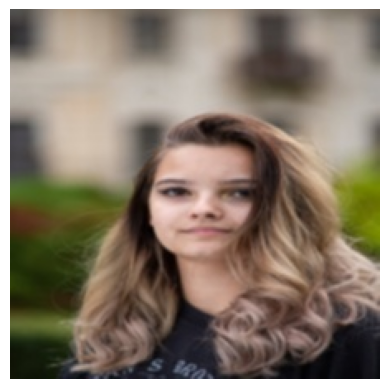

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# Upload file
uploaded = files.upload()

# Get file name
img_path = list(uploaded.keys())[0]

# Show image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')

# Preprocess
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)

# Get class index
class_index = np.argmax(pred)

class_names = ['cat', 'dog', 'person', 'birds', 'table']

print("Prediction:", class_names[class_index])
print("Confidence:", np.max(pred)*100)